# Exploratory Data Analysis - Univariate

Analyze individual features: distributions, summary statistics, outliers, and univariate patterns.

**Author:** Emumena Oweh  
**Project:** Traffic Accident Severity Prediction  
**Dataset:** US Accidents (Kaggle)


# Univariate Analysis

In [75]:
## 1. Numerical Features Analysis

# Get descriptive statistics for numerical columns
print("=" * 80)
print("DESCRIPTIVE STATISTICS - NUMERICAL FEATURES")
print("=" * 80)
numerical_stats = df_clean[num_cols].describe().T
print(numerical_stats)

DESCRIPTIVE STATISTICS - NUMERICAL FEATURES
                      count       mean        std         min         25%  \
Severity           445073.0   2.229850   0.497938    1.000000    2.000000   
Start_Lat          445073.0  36.221185   5.067767   24.562117   33.418552   
Start_Lng          445073.0 -94.776429  17.345755 -124.497420 -117.224213   
Distance(mi)       445073.0   0.513918   1.724851    0.000000    0.000000   
Temperature(F)     445073.0  61.683905  18.862265  -77.800000   49.000000   
Humidity(%)        445073.0  65.041506  22.716492    1.000000   49.000000   
Pressure(in)       445073.0  29.557549   0.988267    0.120000   29.390000   
Visibility(mi)     445073.0   9.101572   2.721360    0.000000   10.000000   
Wind_Speed(mph)    445073.0   7.647183   5.241436    0.000000    5.000000   
Precipitation(in)  445073.0   0.006049   0.090380    0.000000    0.000000   

                         50%        75%         max  
Severity            2.000000   2.000000    4.000000  


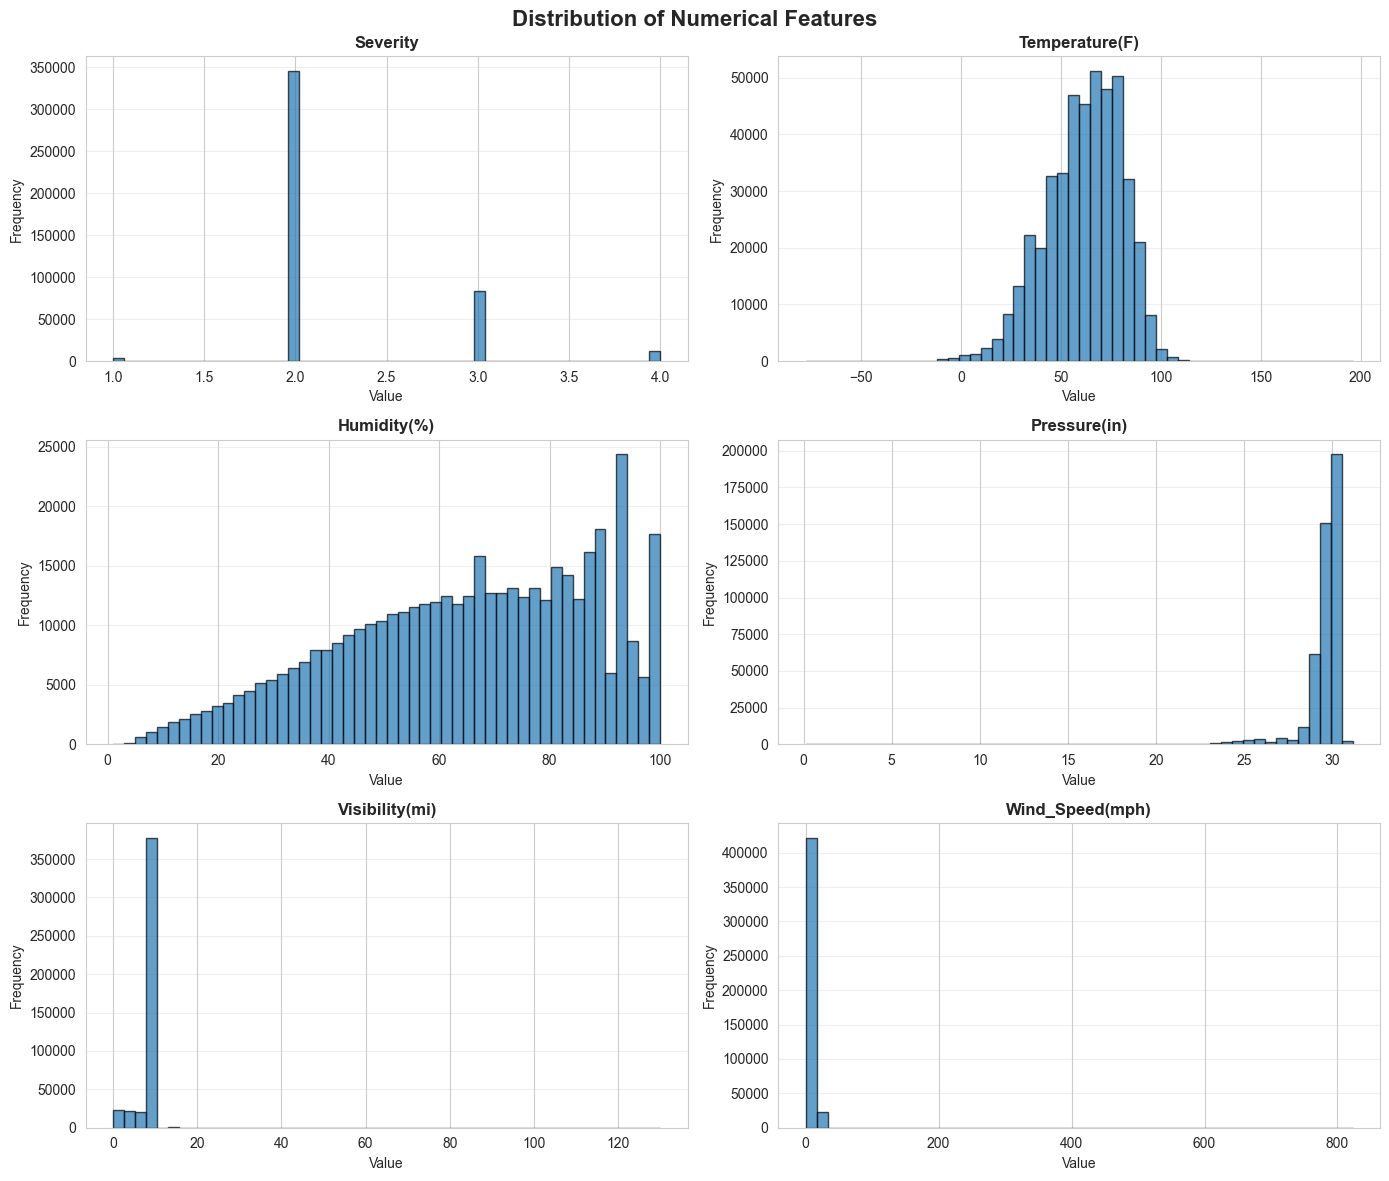

In [76]:
## 2. Numerical Features - Distributions

import os

# Create directory structure
os.makedirs('results/figures/univariate', exist_ok=True)
os.makedirs('results/figures/bivariate', exist_ok=True)

# Create histograms for main numerical features
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

numerical_to_plot = [
    'Severity', 'Temperature(F)', 'Humidity(%)', 
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)'
]

for idx, col in enumerate(numerical_to_plot):
    ax = axes[idx // 2, idx % 2]
    df_clean[col].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}', fontweight='bold')

    ax.set_xlabel('Value')

    ax.set_ylabel('Frequency')

    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/univariate/01_numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

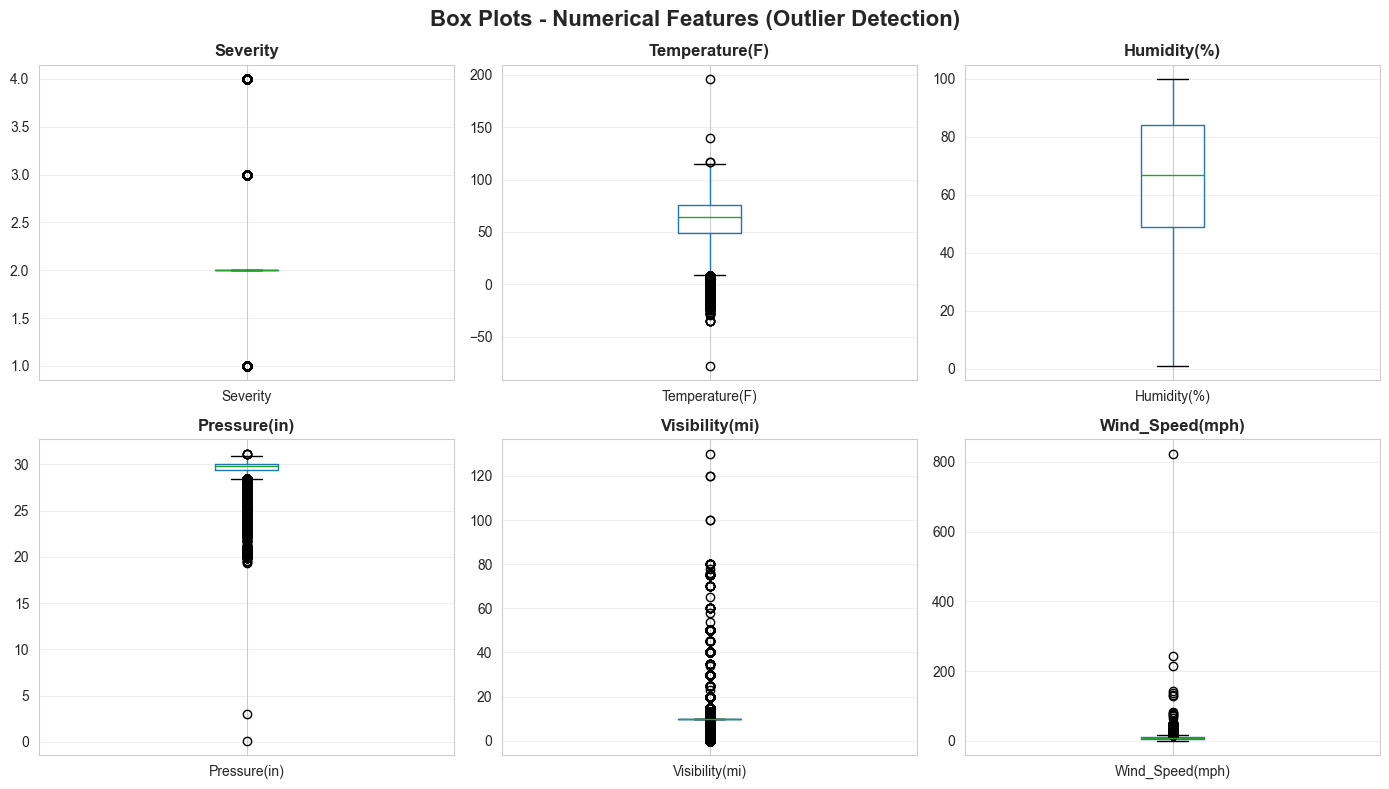

In [77]:
## 3. Numerical Features - Box Plots (Outlier Detection)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Box Plots - Numerical Features (Outlier Detection)', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_to_plot):
    ax = axes[idx // 3, idx % 3]
    df_clean[[col]].boxplot(ax=ax)
    ax.set_title(f'{col}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/univariate/02_boxplots_outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

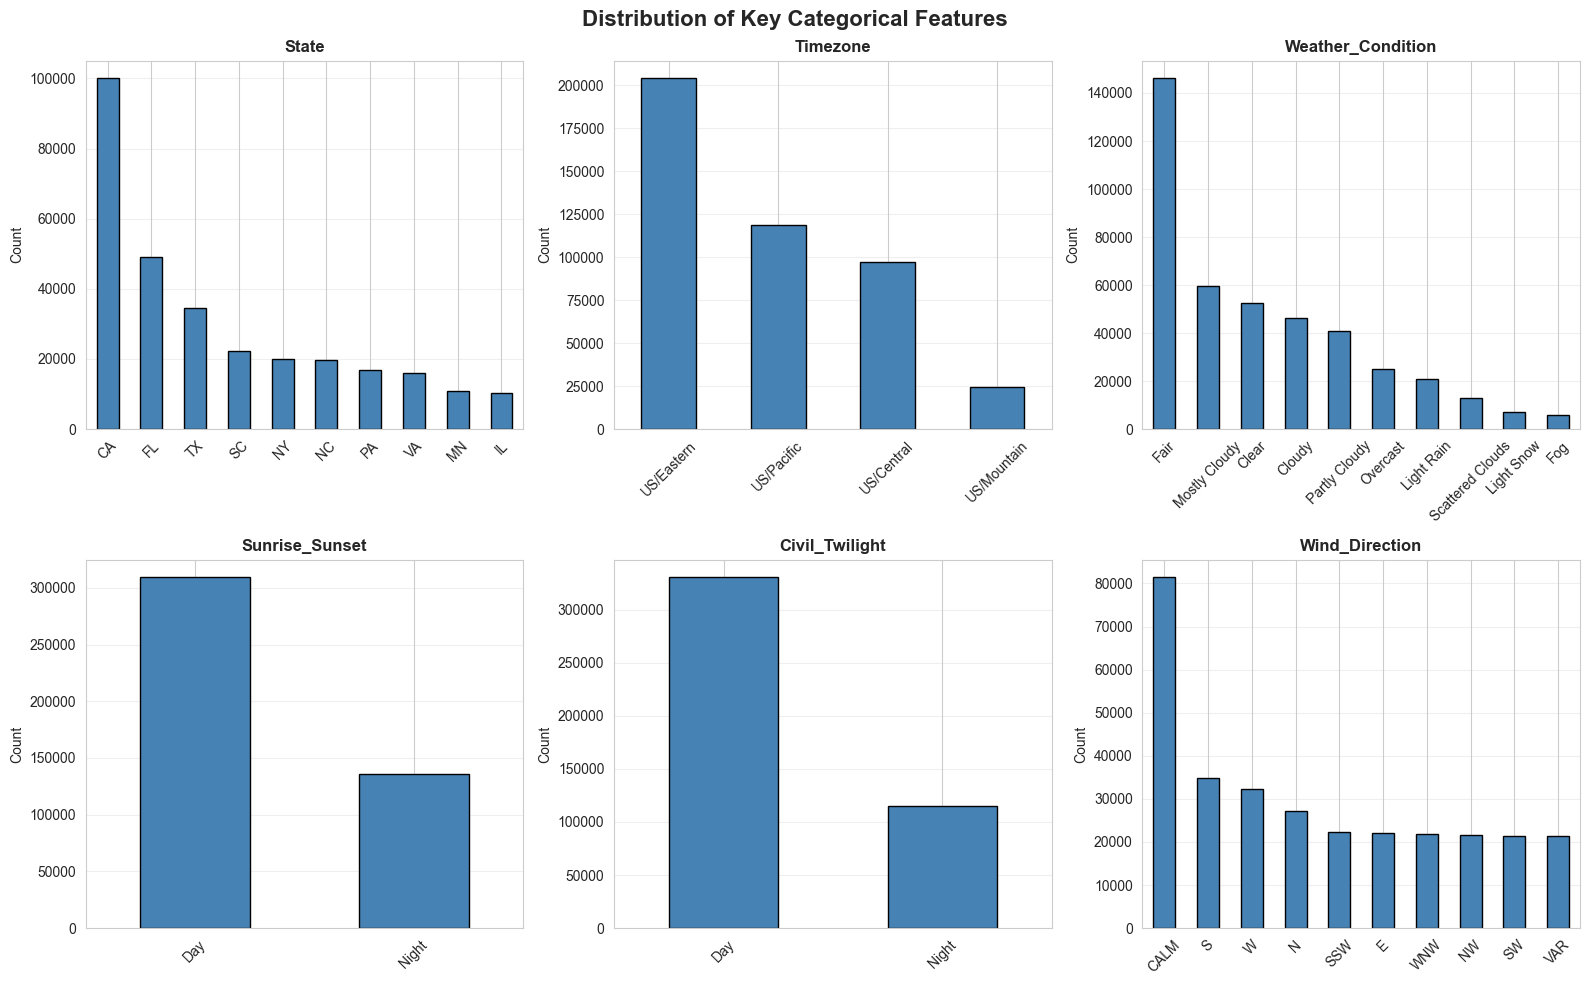

In [78]:
## 5. Categorical Features - Visual Distribution

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Key Categorical Features', fontsize=16, fontweight='bold')

categorical_to_plot = ['State', 'Timezone', 'Weather_Condition', 'Sunrise_Sunset', 
                       'Civil_Twilight', 'Wind_Direction']

for idx, col in enumerate(categorical_to_plot):
    ax = axes[idx // 3, idx % 3]
    top_values = df_clean[col].value_counts().head(10)
    top_values.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/univariate/03_categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


TARGET VARIABLE - SEVERITY ANALYSIS

Severity Distribution:
  Level 1:   4,226 accidents (  0.9%)
  Level 2: 345,878 accidents ( 77.7%)
  Level 3:  83,412 accidents ( 18.7%)
  Level 4:  11,557 accidents (  2.6%)

Severity Statistics:
  Mean: 2.230
  Median: 2.000
  Mode: 2
  Std Dev: 0.498


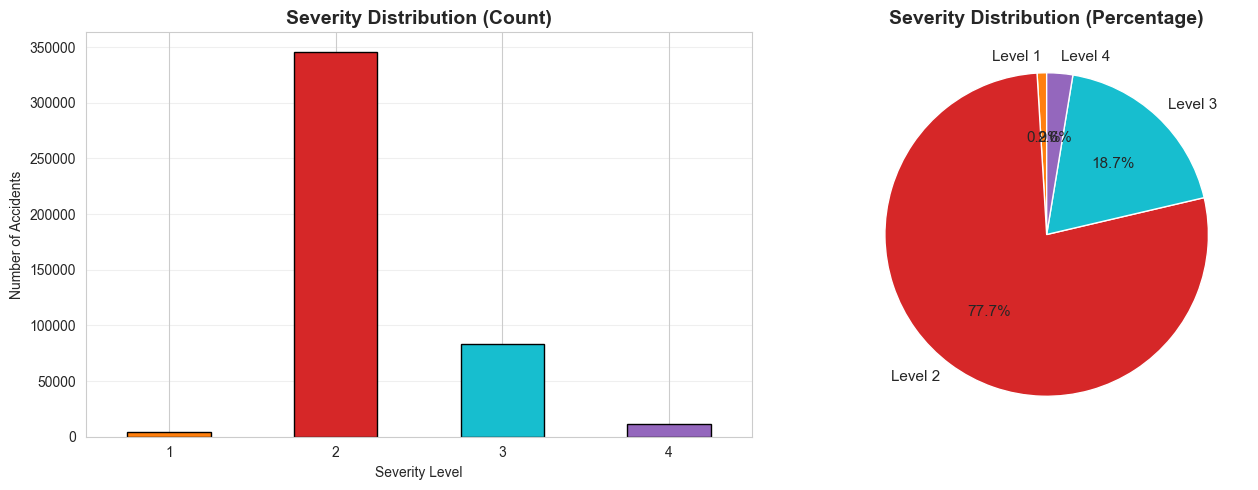

In [79]:
## 6. Target Variable - Severity Distribution

print("\n" + "=" * 80)
print("TARGET VARIABLE - SEVERITY ANALYSIS")
print("=" * 80)

severity_counts = df_clean['Severity'].value_counts().sort_index()
severity_pct = df_clean['Severity'].value_counts(normalize=True).sort_index() * 100

print("\nSeverity Distribution:")
for level in sorted(df_clean['Severity'].unique()):
    count = severity_counts[level]
    pct = severity_pct[level]
    print(f"  Level {int(level)}: {count:>7,} accidents ({pct:>5.1f}%)")

print(f"\nSeverity Statistics:")
print(f"  Mean: {df_clean['Severity'].mean():.3f}")
print(f"  Median: {df_clean['Severity'].median():.3f}")
print(f"  Mode: {df_clean['Severity'].mode()[0]:.0f}")
print(f"  Std Dev: {df_clean['Severity'].std():.3f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
severity_counts.plot(kind='bar', ax=ax1, color=['#ff7f0e', '#d62728', '#17becf', '#9467bd'], edgecolor='black')
ax1.set_title('Severity Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Severity Level')
ax1.set_ylabel('Number of Accidents')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Pie chart
colors = ['#ff7f0e', '#d62728', '#17becf', '#9467bd']
ax2.pie(severity_counts, labels=[f'Level {int(i)}' for i in severity_counts.index], 
        autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 11})
ax2.set_title('Severity Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/univariate/04_severity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


BOOLEAN FEATURES (POINTS OF INTEREST) - PREVALENCE ANALYSIS
Amenity             :   5,563 (  1.2%)
Bump                :     184 (  0.0%)
Crossing            :  51,660 ( 11.6%)
Give_Way            :   2,155 (  0.5%)
Junction            :  33,319 (  7.5%)
No_Exit             :   1,126 (  0.3%)
Railway             :   3,889 (  0.9%)
Roundabout          :      10 (  0.0%)
Station             :  11,585 (  2.6%)
Stop                :  12,525 (  2.8%)
Traffic_Calming     :     417 (  0.1%)
Traffic_Signal      :  69,730 ( 15.7%)
Turning_Loop        :       0 (  0.0%)


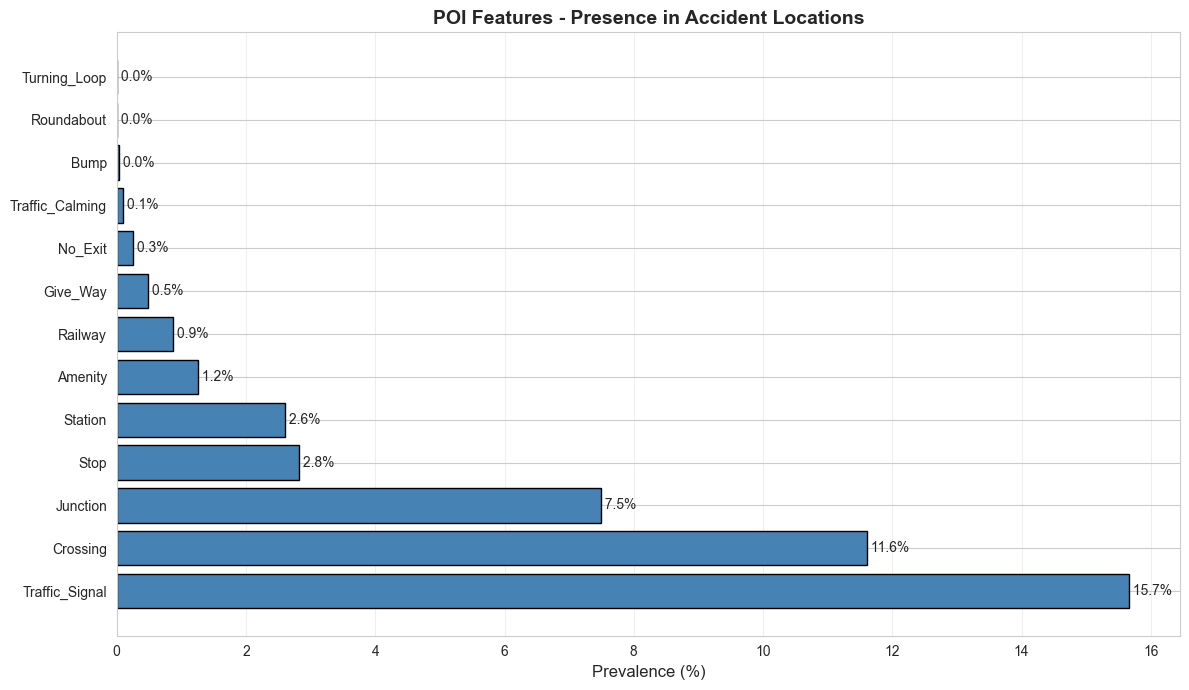

In [80]:
## 7. Boolean Features (POI Indicators) - Prevalence Analysis

poi_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 
                'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 
                'Traffic_Signal', 'Turning_Loop']

print("\n" + "=" * 80)
print("BOOLEAN FEATURES (POINTS OF INTEREST) - PREVALENCE ANALYSIS")
print("=" * 80)

poi_prevalence = {}
for feature in poi_features:
    true_count = (df_clean[feature] == True).sum()
    true_pct = (true_count / len(df_clean)) * 100
    poi_prevalence[feature] = true_pct
    print(f"{feature:20s}: {true_count:>7,} ({true_pct:>5.1f}%)")

# Visualization
fig, ax = plt.subplots(figsize=(12, 7))

poi_sorted = dict(sorted(poi_prevalence.items(), key=lambda x: x[1], reverse=True))
features = list(poi_sorted.keys())
prevalence = list(poi_sorted.values())

bars = ax.barh(features, prevalence, color='steelblue', edgecolor='black')
ax.set_xlabel('Prevalence (%)', fontsize=12)
ax.set_title('POI Features - Presence in Accident Locations', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, prevalence)):
    ax.text(val, i, f' {val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('results/figures/univariate/05_poi_features_prevalence.png', dpi=300, bbox_inches='tight')
plt.show()

In [81]:
## 8. Skewness and Kurtosis Analysis

from scipy import stats

print("\n" + "=" * 80)
print("SKEWNESS & KURTOSIS ANALYSIS - NUMERICAL FEATURES")
print("=" * 80)
print(f"{'Feature':<20} {'Skewness':>12} {'Kurtosis':>12} {'Distribution':>20}")
print("-" * 80)

for col in numerical_to_plot:
    skew = stats.skew(df_clean[col])
    kurt = stats.kurtosis(df_clean[col])
    
    if abs(skew) < 0.5:
        dist = "Fairly Symmetric"
    elif skew > 0:
        dist = "Right-skewed"
    else:
        dist = "Left-skewed"
    
    print(f"{col:<20} {skew:>12.3f} {kurt:>12.3f} {dist:>20}")

print("\nNote: Skewness values:")
print("  -0.5 to 0.5: Fairly symmetric")
print("  0.5 to 1 or -1 to -0.5: Moderately skewed")
print("  > 1 or < -1: Highly skewed")


SKEWNESS & KURTOSIS ANALYSIS - NUMERICAL FEATURES
Feature                  Skewness     Kurtosis         Distribution
--------------------------------------------------------------------------------
Severity                    1.641        2.608         Right-skewed
Temperature(F)             -0.510        0.015          Left-skewed
Humidity(%)                -0.410       -0.695     Fairly Symmetric
Pressure(in)               -3.814       20.423          Left-skewed
Visibility(mi)              3.011       99.932         Right-skewed
Wind_Speed(mph)             9.692     1333.342         Right-skewed

Note: Skewness values:
  -0.5 to 0.5: Fairly symmetric
  0.5 to 1 or -1 to -0.5: Moderately skewed
  > 1 or < -1: Highly skewed


In [14]:
# Check Wind_Speed outliers
print("Wind_Speed Statistics:")
print(df_clean['Wind_Speed(mph)'].describe())
print(f"\nMax value: {df_clean['Wind_Speed(mph)'].max()}")
print(f"99th percentile: {df_clean['Wind_Speed(mph)'].quantile(0.99)}")

# Check Pressure outliers
print("\n\nPressure Statistics:")
print(df_clean['Pressure(in)'].describe())
print(f"\nMin value: {df_clean['Pressure(in)'].min()}")
print(f"1st percentile: {df_clean['Pressure(in)'].quantile(0.01)}")

Wind_Speed Statistics:
count    445073.000000
mean          7.647183
std           5.241436
min           0.000000
25%           5.000000
50%           7.000000
75%          10.000000
max         822.800000
Name: Wind_Speed(mph), dtype: float64

Max value: 822.8
99th percentile: 23.0


Pressure Statistics:
count    445073.000000
mean         29.557549
std           0.988267
min           0.120000
25%          29.390000
50%          29.870000
75%          30.040000
max          31.150000
Name: Pressure(in), dtype: float64

Min value: 0.12
1st percentile: 24.63
